In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Gurgaon_properties_cleaned.csv')

In [3]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,...,NaN,NaN,900.0,0,0,0,0,0,unfurnished,28
1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,...,NaN,NaN,650.0,0,0,0,0,0,semifurnished,37
2,flat,tulsiani easy in homes,sohna road,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,...,NaN,NaN,595.0,0,0,0,0,0,unfurnished,36
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,...,NaN,NaN,1200.0,1,0,0,0,0,unfurnished,76
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,...,1345.0,NaN,NaN,1,0,0,0,0,unfurnished,0


In [4]:
df.shape

(3615, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3615 entries, 0 to 3614
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3615 non-null   object 
 1   society              3614 non-null   object 
 2   sector               3615 non-null   object 
 3   price                3598 non-null   float64
 4   price_per_sqft       3598 non-null   float64
 5   area                 3598 non-null   float64
 6   areaWithType         3615 non-null   object 
 7   bedRoom              3615 non-null   int64  
 8   bathroom             3615 non-null   int64  
 9   balcony              3615 non-null   object 
 10  floorNum             3596 non-null   float64
 11  facing               2597 non-null   object 
 12  agePossession        3615 non-null   object 
 13  super_built_up_area  1869 non-null   float64
 14  built_up_area        1647 non-null   float64
 15  carpet_area          1852 non-null   f

## 1.property_type

<Axes: xlabel='property_type'>

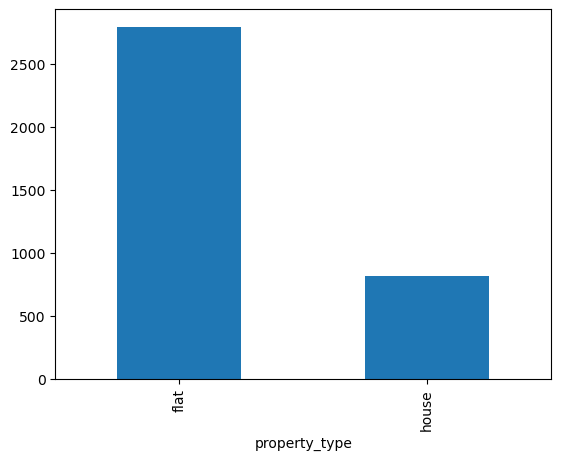

In [6]:
df['property_type'].value_counts().plot(kind='bar',)

### Observation

- Around 75% of properties are flats and 25% are houses.
- No missing values.

## 2.society

In [7]:
df['society'].value_counts()

society
independent                             471
tulip violet                             75
ss the leaf                              73
shapoorji pallonji joyville gurugram     42
dlf new town heights                     41
                                       ... 
tashee capital gateway                    1
raheja atlantis                           1
shree vardhman mantra                     1
the new crpf apartments                   1
huda floor                                1
Name: count, Length: 651, dtype: int64

In [8]:
df['society'].value_counts().shape

(651,)

In [9]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(72)

society
tulip violet                            0.023863
ss the leaf                             0.047089
shapoorji pallonji joyville gurugram    0.060452
dlf new town heights                    0.073497
signature global park                   0.084633
                                          ...   
dlf the primus                          0.483933
ansal heights 86                        0.488069
ats kocoon                              0.492205
umang winter hills                      0.496341
ramsons kshitij                         0.500477
Name: proportion, Length: 72, dtype: float64

In [10]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': 1,
 'High (50-100)': 2,
 'Average (10-49)': 92,
 'Low (2-9)': 264,
 'Very Low (1)': 292}

<Axes: xlabel='society'>

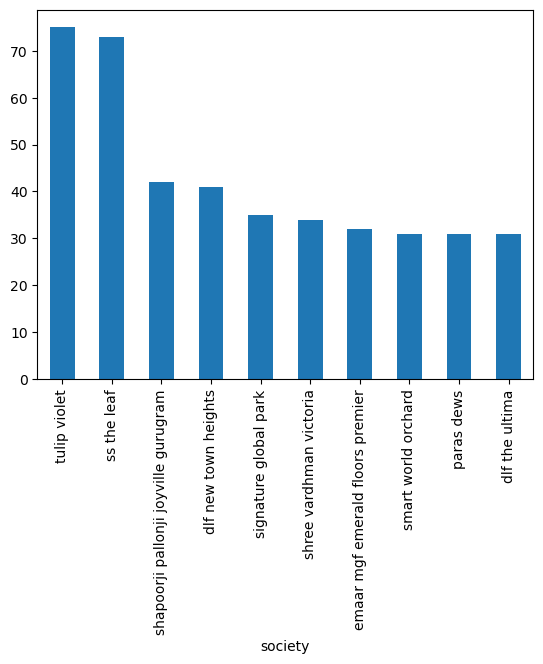

In [11]:
df[df['society']!='independent']['society'].value_counts().head(10).plot(kind='bar')

In [12]:
df['society'].isnull().sum()

1

In [13]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2570,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,unfurnished,0


In [14]:
(471/3615)*100

13.029045643153529

In [15]:
651-72

579

### Observation

- Around **13%** of properties come under the **independent** tag.
- There are **651 societies**.
- The top **72 societies** account for **50%** of the properties, while the remaining **50%** come from the other **579 societies**.
    - **Very High (>100):** Only **1** society has more than **100** listings.
    - **High (50–100):** **2** societies have between **50** and **100**     listings.
    - **Average (10–49):** **92** societies fall in this range.
    - **Low (2–9):** **263** societies have between **2** and **9** listings.
    - **Very Low (1):** **294** societies have only **1** listing.
- There is **1 missing value**.

## 3.sector

In [16]:
df['sector'].value_counts().shape

(96,)

<Axes: xlabel='sector'>

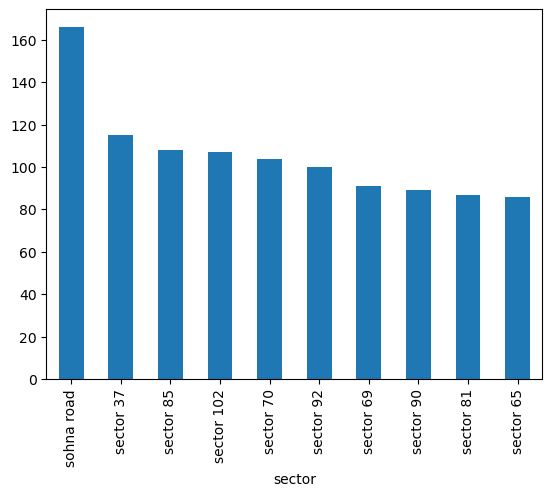

In [17]:
# top 10 sectors
df['sector'].value_counts().head(10).plot(kind='bar')

In [18]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': 5,
 'High (50-100)': 23,
 'Average (10-49)': 52,
 'Low (2-9)': 16,
 'Very Low (1)': 0}

### Observations

- There are a total of **96 unique sectors** in the dataset.

- Frequency distribution of sectors:
    - **Very High (>100):** 5 sectors have more than 100 listings.
    - **High (50–100):** 23 sectors have between 50 and 100 listings.
    - **Average (10–49):** A majority of 52 sectors fall in this range, with 10 to 49 listings each.
    - **Low (2–9):** 16 sectors have between 2 and 9 listings.
    - **Very Low (1):** Interestingly, there are no sectors with only 1 listing.

## 4.price

In [19]:
df['price'].isnull().sum()

17

In [20]:
df['price'].describe()

count    3598.000000
mean        2.523066
std         2.965214
min         0.070000
25%         0.950000
50%         1.520000
75%         2.715000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

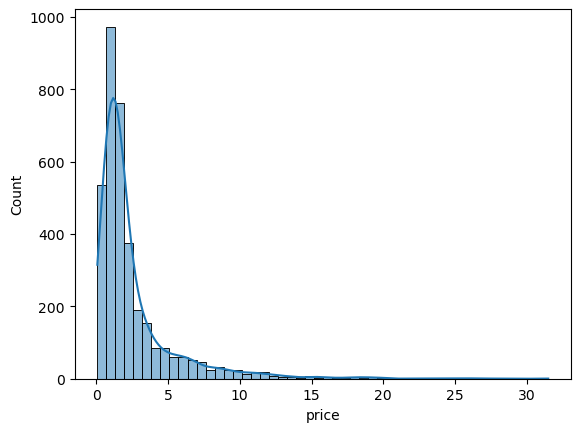

In [21]:
sns.histplot(df['price'], kde=True, bins=50)

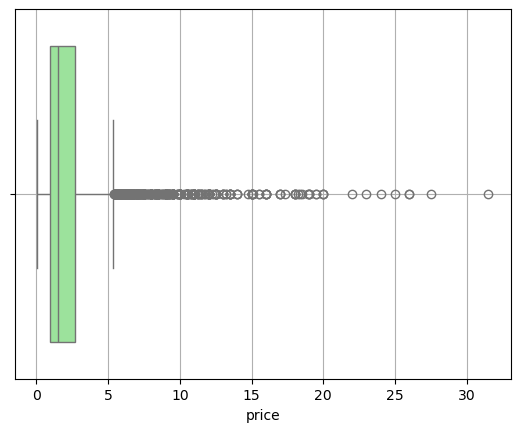

In [22]:
sns.boxplot(x=df['price'], color='lightgreen')
plt.grid()

In [23]:
df[df['price'] >10].shape

(116, 23)

In [24]:
skewness = df['price'].skew()
kurtosis = df['price'].kurt()
print(skewness,kurtosis)

3.3035309601029463 15.24014522426635


**Skewness:** The price distribution has a skewness of approximately 3.30, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

**Kurtosis:** The kurtosis value is approximately 15.23. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [25]:
quantiles = df['price'].quantile([0.01, 0.05,0.5, 0.95, 0.99])

In [26]:
quantiles

0.01     0.250
0.05     0.380
0.50     1.520
0.95     8.500
0.99    15.003
Name: price, dtype: float64

### **Quantile Analysis**
- 1% Quantile: Only 1% of properties are priced below 0.25 crores.
- 5% Quantile: 5% of properties are priced below 0.38 crores.
- 95% Quantile: 95% of properties are priced below 8.5 crores.
- 99% Quantile: 99% of properties are priced below 15 crores, indicating that very few properties are priced above this value.

In [27]:
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

print(Q1,Q3,IQR)

0.95 2.7150000000000003 1.7650000000000003


In [28]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.6975000000000005 5.362500000000001


Descreptive Statistics

- Average price is 2.52 cr
- Range of price of property is 7 lac to 31.5 Cr
- IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.95 crores to 2.71 crores.
- Median Price is 1.5 cr
  
Visualizations:

- Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
- Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.

Missing Values: There are 17 missing values in the price column.

In [29]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(418, 23)

In [30]:
outliers['price'].describe()

count    418.000000
mean       9.183780
std        4.059181
min        5.400000
25%        6.410000
50%        8.000000
75%       10.557500
max       31.500000
Name: price, dtype: float64

Outliers Analysis (using IQR method):

- Based on the IQR method, there are 418 properties considered as outliers.
- These outliers have an average price of approximately 9.18 crores.
- The range for these outliers is from 5.4 crores to 31.5 crores.

<Axes: xlabel='price'>

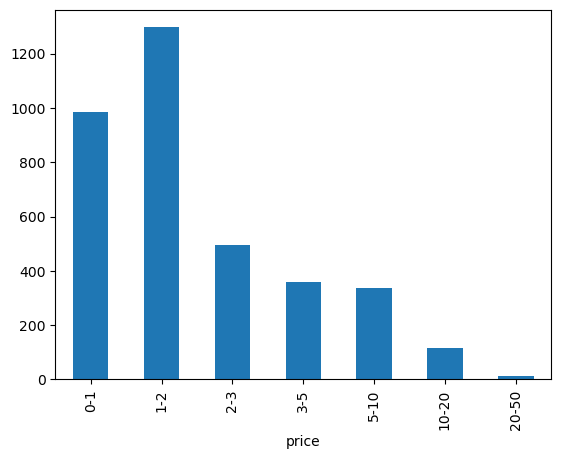

In [31]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

- The majority of properties are priced in the "1-2 crores" and "0-1 crores" ranges.
- There's a significant drop in the number of properties priced above "5 crores."

<Axes: xlabel='price', ylabel='Proportion'>

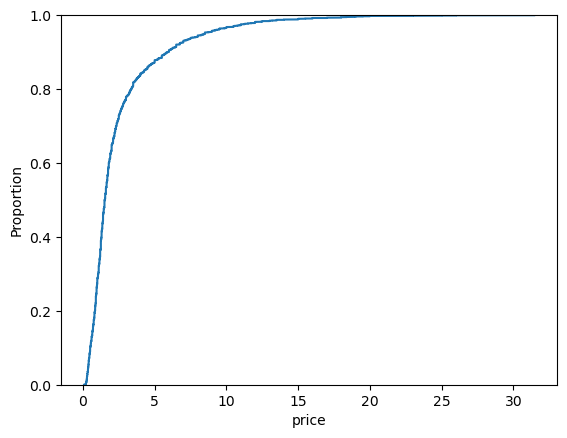

In [32]:
sns.ecdfplot(df['price'])

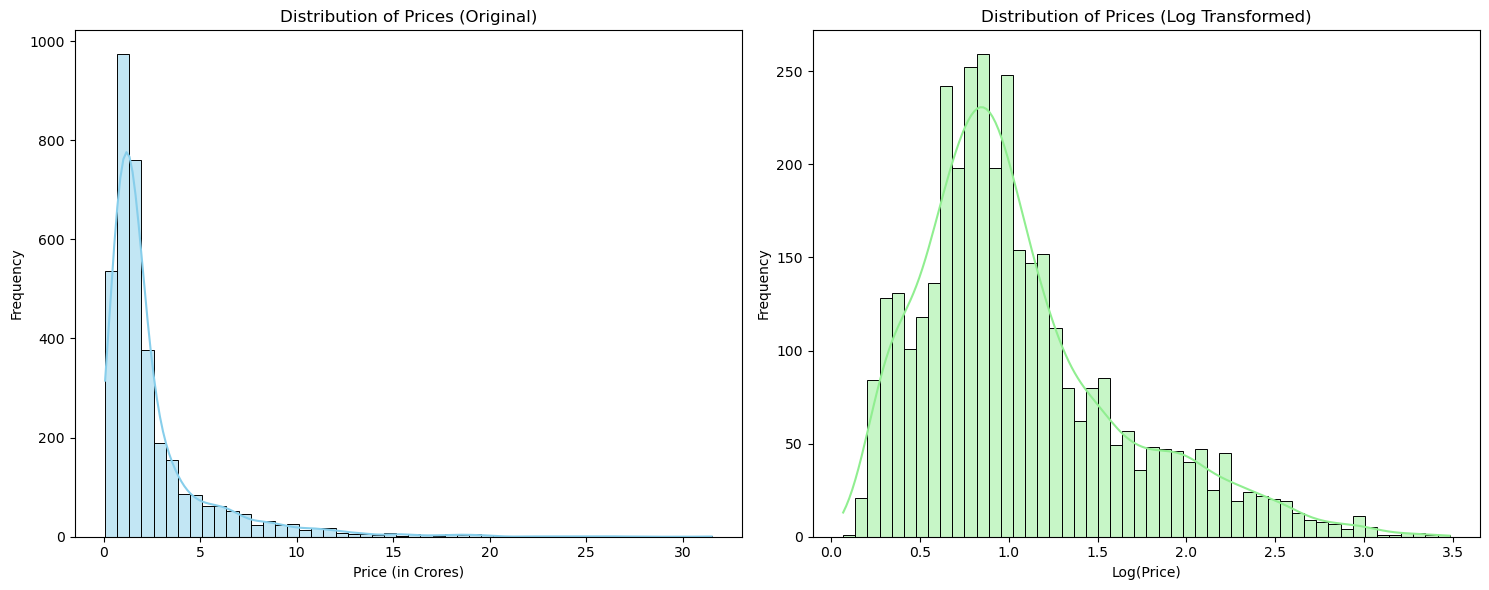

In [33]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [34]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0807358405166911 0.987733389854796


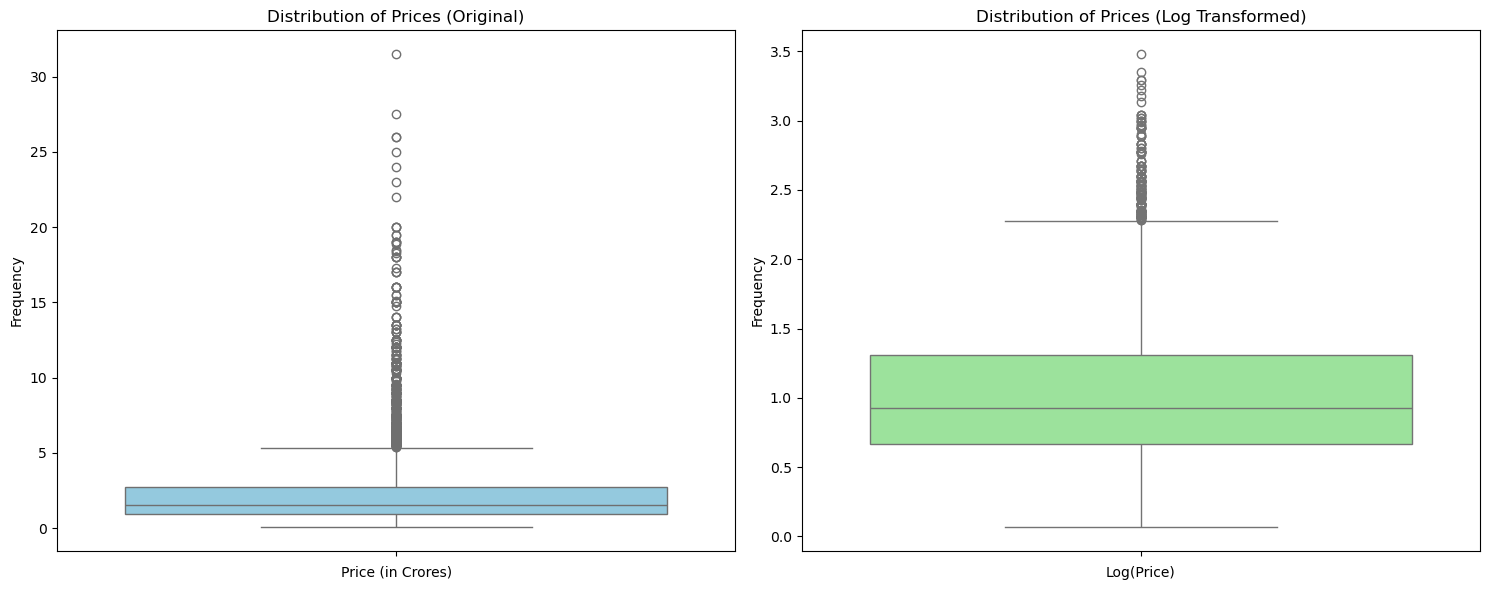

In [35]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## 5.price_pr_sqft

In [36]:
df['price_per_sqft'].isnull().sum()

17

In [37]:
df['price_per_sqft'].describe()

count      3598.000000
mean      13910.947471
std       23381.649821
min           4.000000
25%        6818.000000
50%        9001.000000
75%       13825.250000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

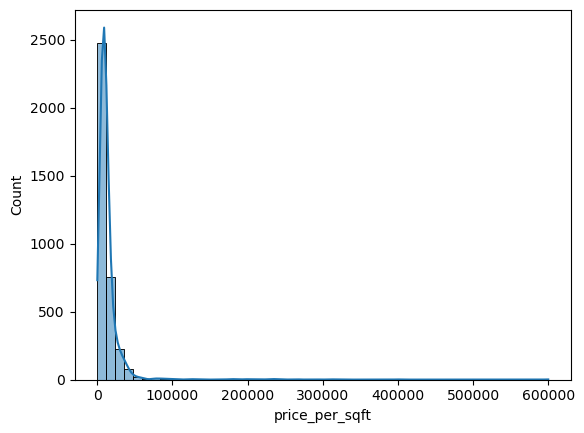

In [38]:
sns.histplot(df['price_per_sqft'],bins=50,kde=True)

In [39]:
df[df['price_per_sqft'] == 4]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2371,flat,hcbs sports ville,sohna road,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,...,NaN,737147.0,NaN,0,0,0,0,0,furnished,44


<Axes: ylabel='price_per_sqft'>

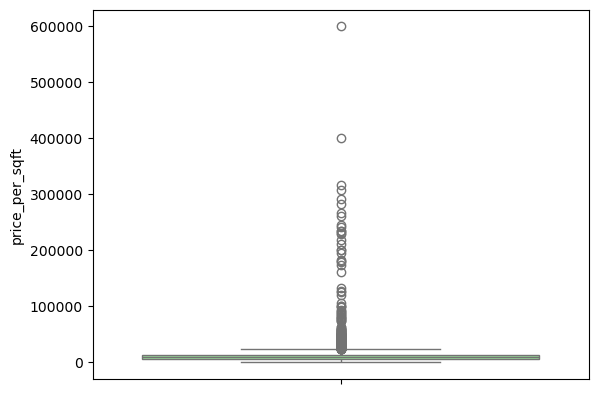

In [40]:
sns.boxplot(df['price_per_sqft'], color='lightgreen')

The box plot clearly shows several outliers, especially on the higher side. The interquartile range (IQR) is relatively compact, but there are many data points beyond the "whiskers" of the box plot, indicating potential outliers

### Observation
- data is right skewed
- there are 17 null values
- potential outliers

## 6.bedRoom

<Axes: xlabel='bedRoom'>

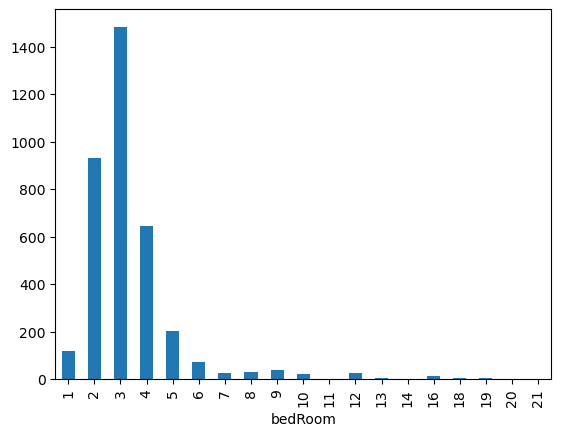

In [41]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

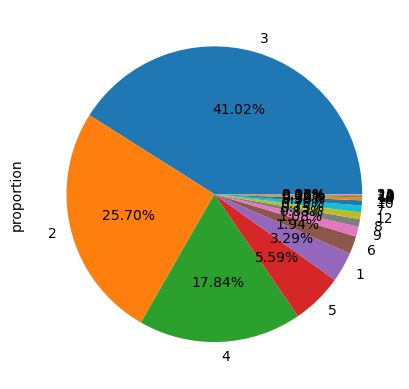

In [42]:
df['bedRoom'].value_counts(normalize=True).plot(kind='pie',autopct='%0.2f%%')

In [43]:
df['bedRoom'].isnull().sum()

0

## 7.bathroom

In [44]:
df['bathroom'].isnull().sum()

0

<Axes: xlabel='bathroom'>

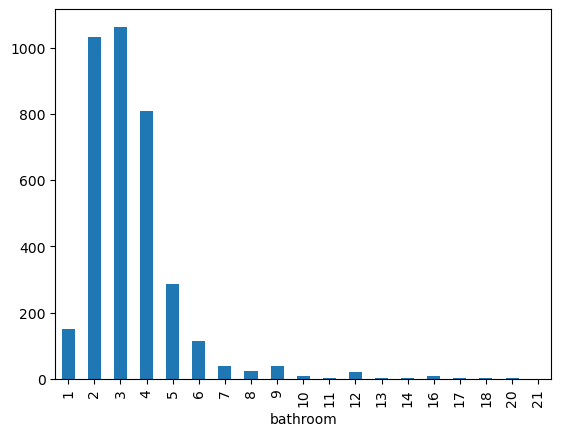

In [45]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

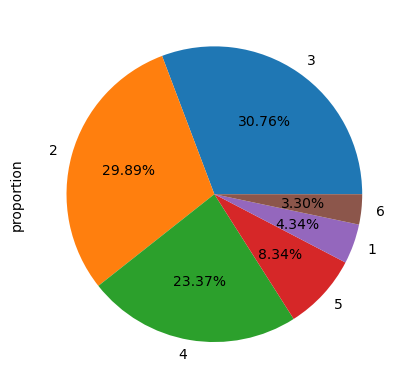

In [46]:
df['bathroom'].value_counts(normalize=True).head(6).plot(kind='pie',autopct='%0.2f%%')

## 8.balcony

<Axes: xlabel='balcony'>

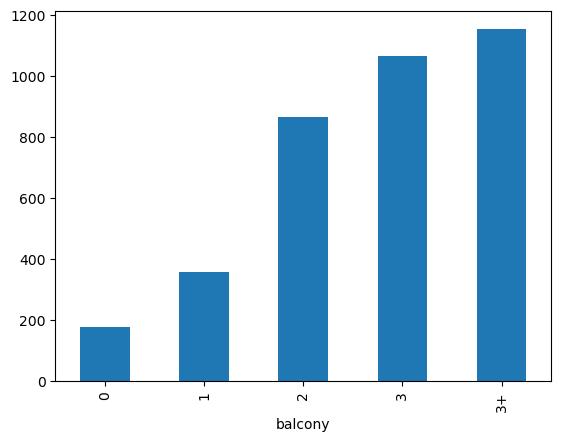

In [47]:
df['balcony'].value_counts().sort_index().plot(kind='bar')

In [48]:
df['balcony'].isnull().sum()

0

<Axes: ylabel='proportion'>

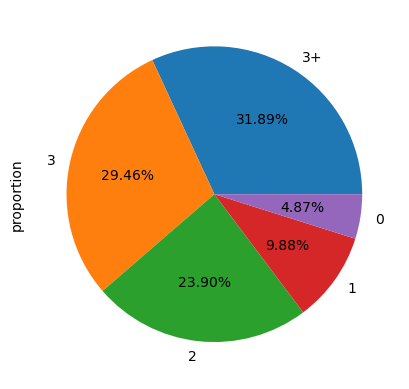

In [49]:
df['balcony'].value_counts(normalize=True).plot(kind='pie',autopct='%0.2f%%')

## 9.floorNum

In [50]:
df.floorNum.isnull().sum()

19

In [51]:
df.iloc[:,10:].head()

,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,4.0,West,Relatively New,NaN,NaN,900.0,0,0,0,0,0,unfurnished,28
1,1.0,West,Old Property,NaN,NaN,650.0,0,0,0,0,0,semifurnished,37
2,12.0,NaN,New Property,NaN,NaN,595.0,0,0,0,0,0,unfurnished,36
3,2.0,NaN,Relatively New,NaN,NaN,1200.0,1,0,0,0,0,unfurnished,76
4,5.0,NaN,Under Construction,1345.0,NaN,NaN,1,0,0,0,0,unfurnished,0


In [52]:
df.floorNum.describe()

count    3596.000000
mean        6.835373
std         6.010203
min        -1.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

<Axes: xlabel='floorNum'>

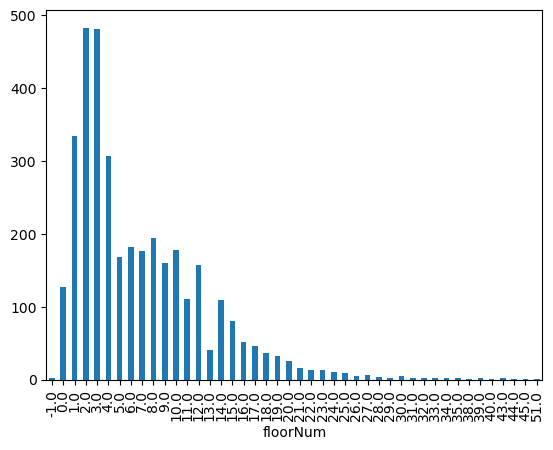

In [53]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='floorNum'>

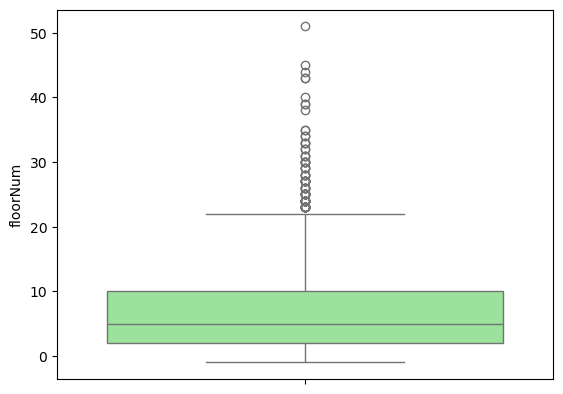

In [54]:
sns.boxplot(df['floorNum'], color='lightgreen')

- The majority of the properties lie between the ground floor (0) and the 25th floor.
- Floors 1 to 4 are particularly common, with the 3rd floor being the most frequent.
- There are a few properties located at higher floors, but their frequency is much lower.
- The box plot reveals that the majority of the properties are concentrated around the lower floors. The interquartile range (IQR) lies between approximately the 2nd and 10th floors.
- Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers.

## 10.facing

In [55]:
df.facing.isnull().sum()

1018

In [56]:
df['facing'].fillna('NA',inplace=True)

C:\Users\manoj\AppData\Local\Temp\ipykernel_13364\3692945726.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna('NA',inplace=True)


In [57]:
df['facing'].value_counts()

facing
NA            1018
North-East     615
East           614
North          380
West           246
South          231
North-West     188
South-East     171
South-West     152
Name: count, dtype: int64

<Axes: xlabel='facing'>

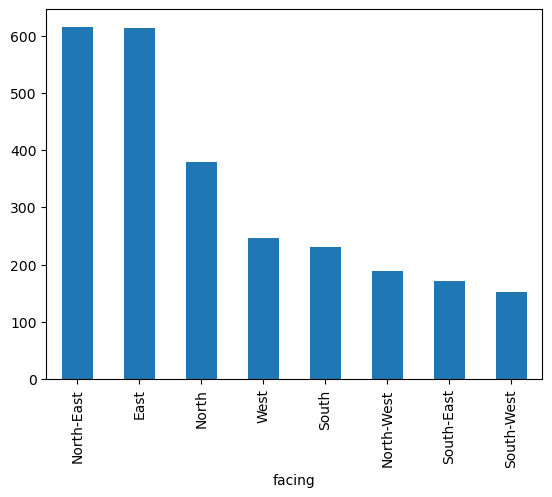

In [58]:
df[df['facing'] != 'NA']['facing'].value_counts().plot(kind='bar')

## 11.agePossession

In [59]:
df['agePossession'].isnull().sum()

0

In [60]:
df['agePossession'].value_counts()

agePossession
Relatively New        1733
New Property           609
Moderately Old         556
Undefined              295
Old Property           291
Under Construction     131
Name: count, dtype: int64

## 12.areas

In [61]:
df['super_built_up_area'].isnull().sum()

1746

In [62]:
df['super_built_up_area'].describe()

count     1869.000000
mean      1926.690503
std        763.372694
min         89.000000
25%       1480.000000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

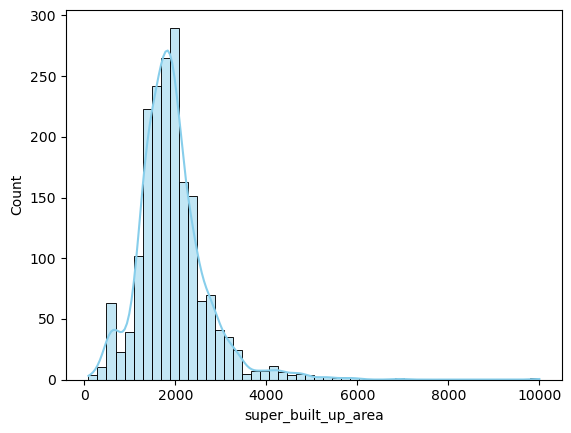

In [63]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)     

<Axes: ylabel='super_built_up_area'>

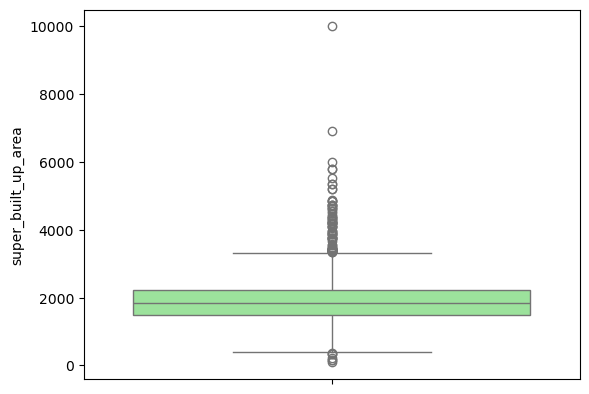

In [64]:
sns.boxplot(df['super_built_up_area'].dropna(), color='lightgreen')

- Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
- There are a few properties with a significantly larger area, leading to a right-skewed distribution.
- The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.
- There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

In [65]:
df['built_up_area'].isnull().sum()

1968

In [66]:
df['built_up_area'].describe()

count      1647.000000
mean       2380.729222
std       18172.757792
min           2.000000
25%        1103.000000
50%        1650.000000
75%        2394.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

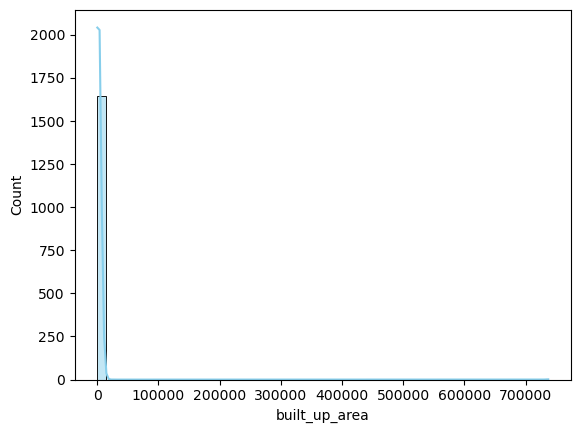

In [67]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='built_up_area'>

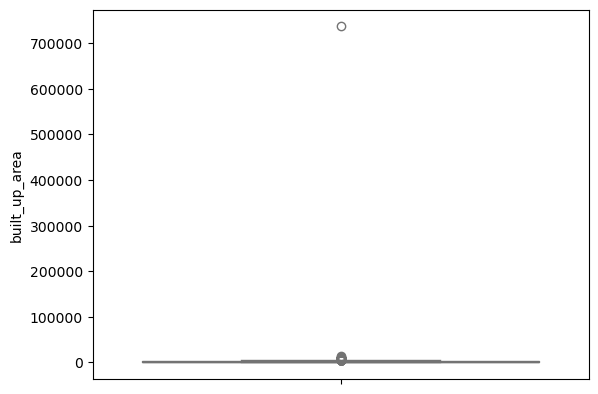

In [68]:
sns.boxplot(df['built_up_area'].dropna(), color='lightgreen')

- Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.
- There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.
- The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.
- The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors. This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.

In [69]:
df['carpet_area'].isnull().sum()

1763

In [70]:
df['carpet_area'].describe()

count      1852.000000
mean       2543.541057
std       22922.100064
min          15.000000
25%         845.000000
50%        1300.000000
75%        1790.250000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

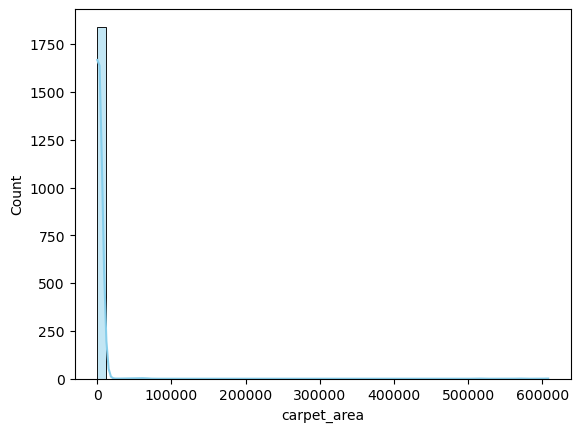

In [71]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='carpet_area'>

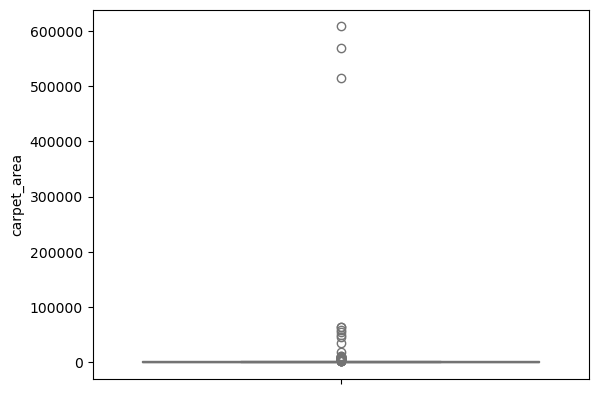

In [72]:
sns.boxplot(df['carpet_area'].dropna(), color='lightgreen')

## 13.additionL Roons

In [82]:
df.iloc[:,16:]

,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,0,0,0,0,unfurnished,28
1,0,0,0,0,0,semifurnished,37
2,0,0,0,0,0,unfurnished,36
3,1,0,0,0,0,unfurnished,76
4,1,0,0,0,0,unfurnished,0
...,...,...,...,...,...,...,...
3610,0,0,1,0,0,semifurnished,96
3611,1,1,0,1,0,unfurnished,69
3612,1,0,0,0,0,unfurnished,35
3613,1,1,0,0,0,unfurnished,70


In [84]:
for i,j in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    print (i,j)

1 study room
2 servant room
3 store room
4 pooja room
5 others


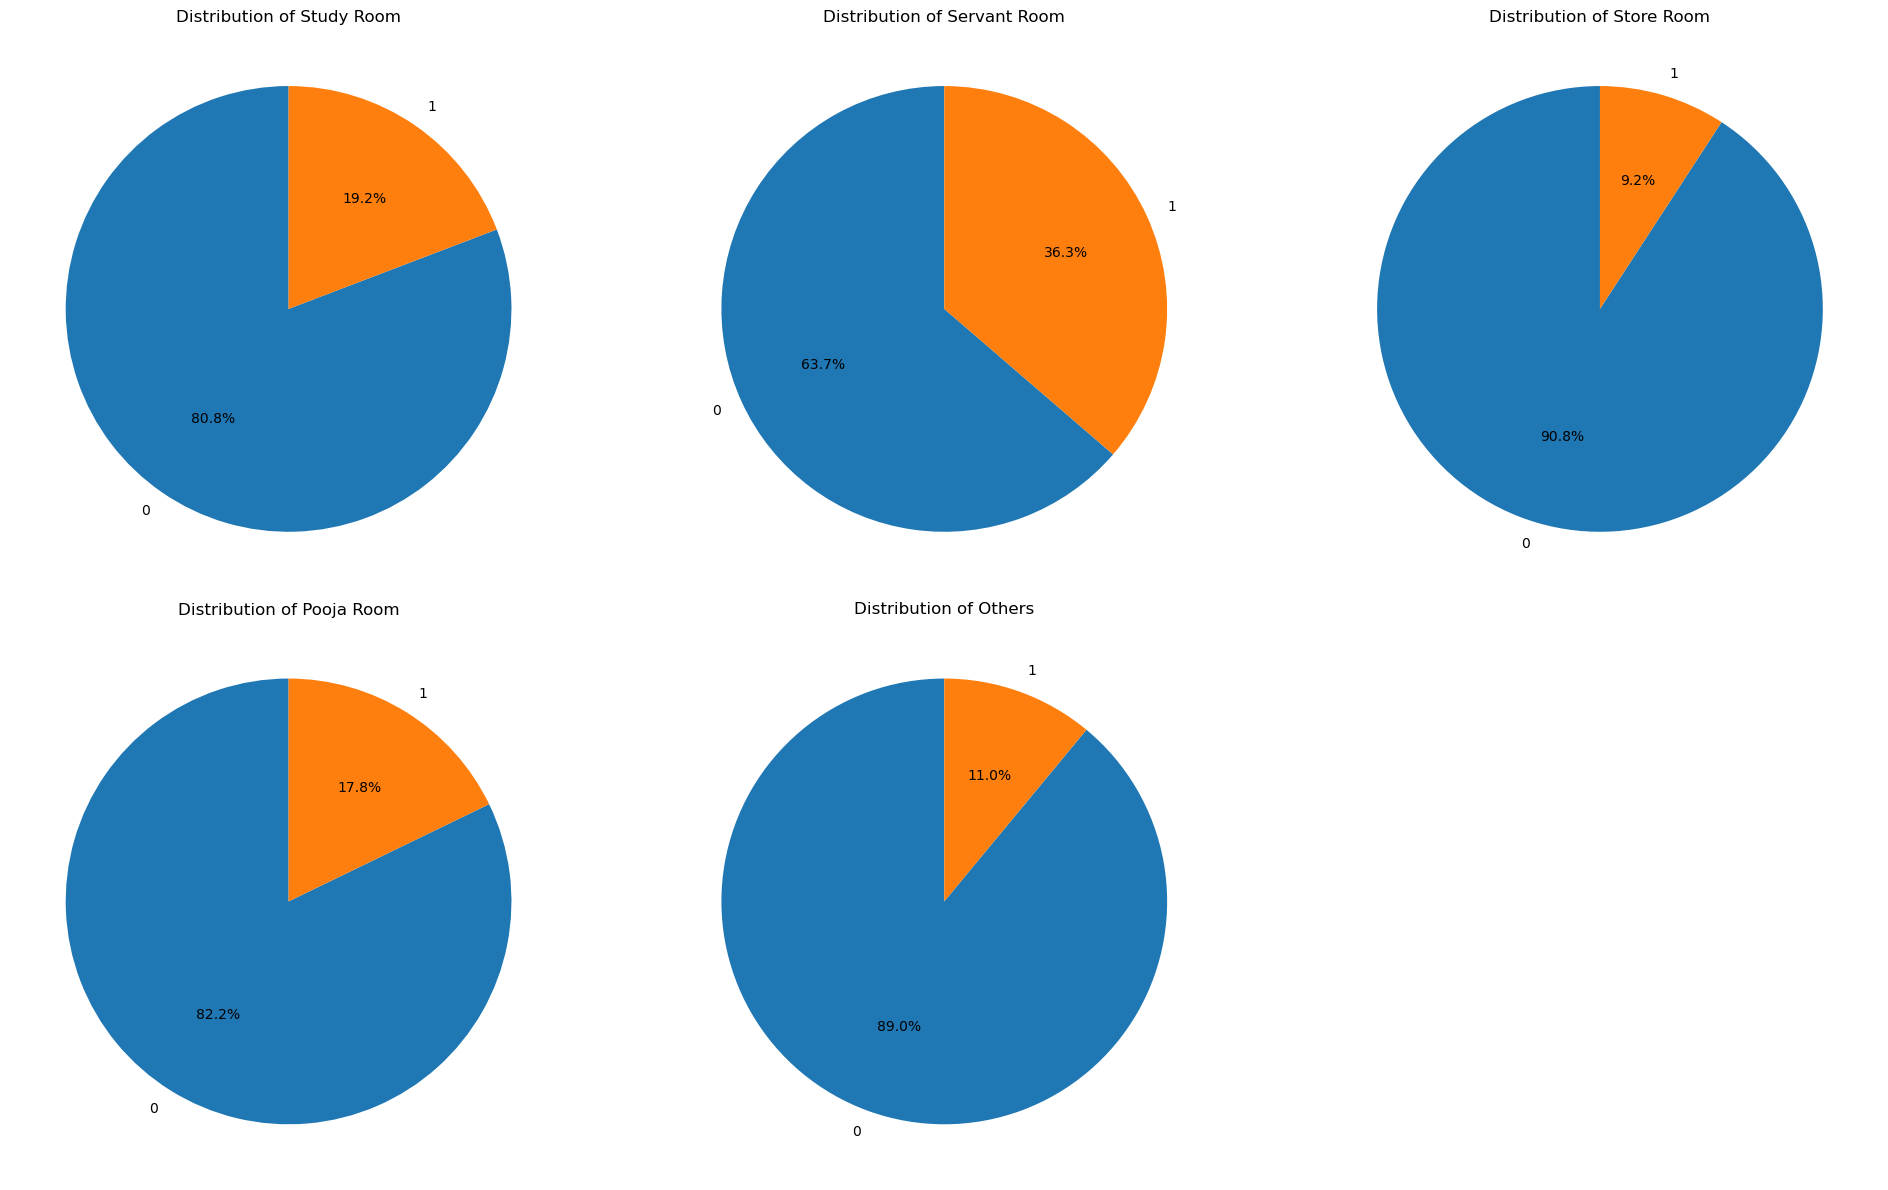

In [87]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

## 14.furnishing_type

In [73]:
df['furnishing_type'].value_counts()

furnishing_type
unfurnished      2391
semifurnished    1023
furnished         201
Name: count, dtype: int64

In [74]:
df.loc[df['furnishing_type'] == 0, 'furnishing_type'] = 'unfurnished'
df.loc[df['furnishing_type'] == 1, 'furnishing_type'] = 'furnished'
df.loc[df['furnishing_type'] == 2, 'furnishing_type'] = 'semifurnished'

In [75]:
df['furnishing_type'].value_counts()

furnishing_type
unfurnished      2391
semifurnished    1023
furnished         201
Name: count, dtype: int64

<Axes: ylabel='count'>

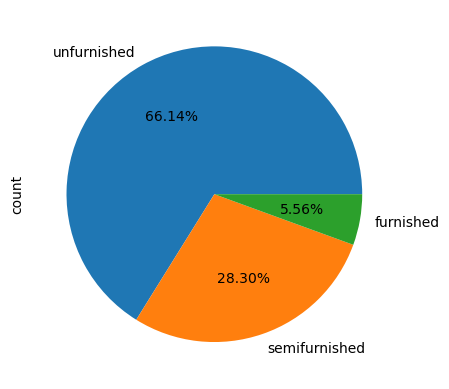

In [76]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [77]:
df.to_csv('Gurgaon_properties_cleaned(1).csv', index=False)

## 15.luxury_score

In [78]:
df['luxury_score'].isnull().sum()

0

In [79]:
df['luxury_score'].describe()

count    3615.000000
mean       71.976487
std        53.038742
min         0.000000
25%        33.000000
50%        60.000000
75%       110.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

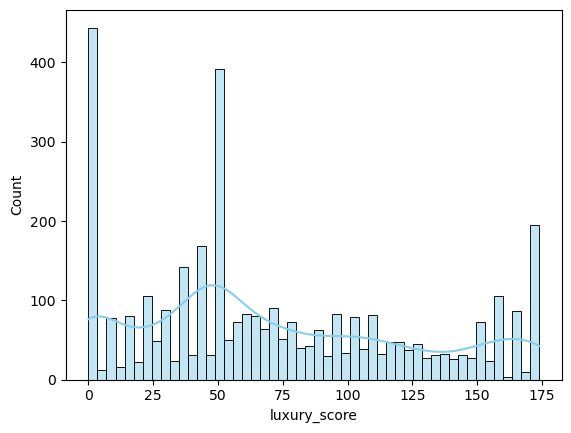

In [80]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='luxury_score'>

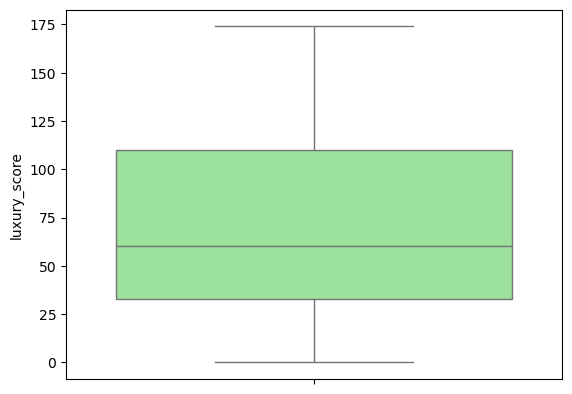

In [81]:
sns.boxplot(df['luxury_score'], color='lightgreen')